## Resultant file analysis

Compare the geometry distributions in ethene files with the ethene dynamic data retained by the default `shnitsel` sanity filter. Each histogram includes every equivalent bond, angle, or carbon site in its input geometries.


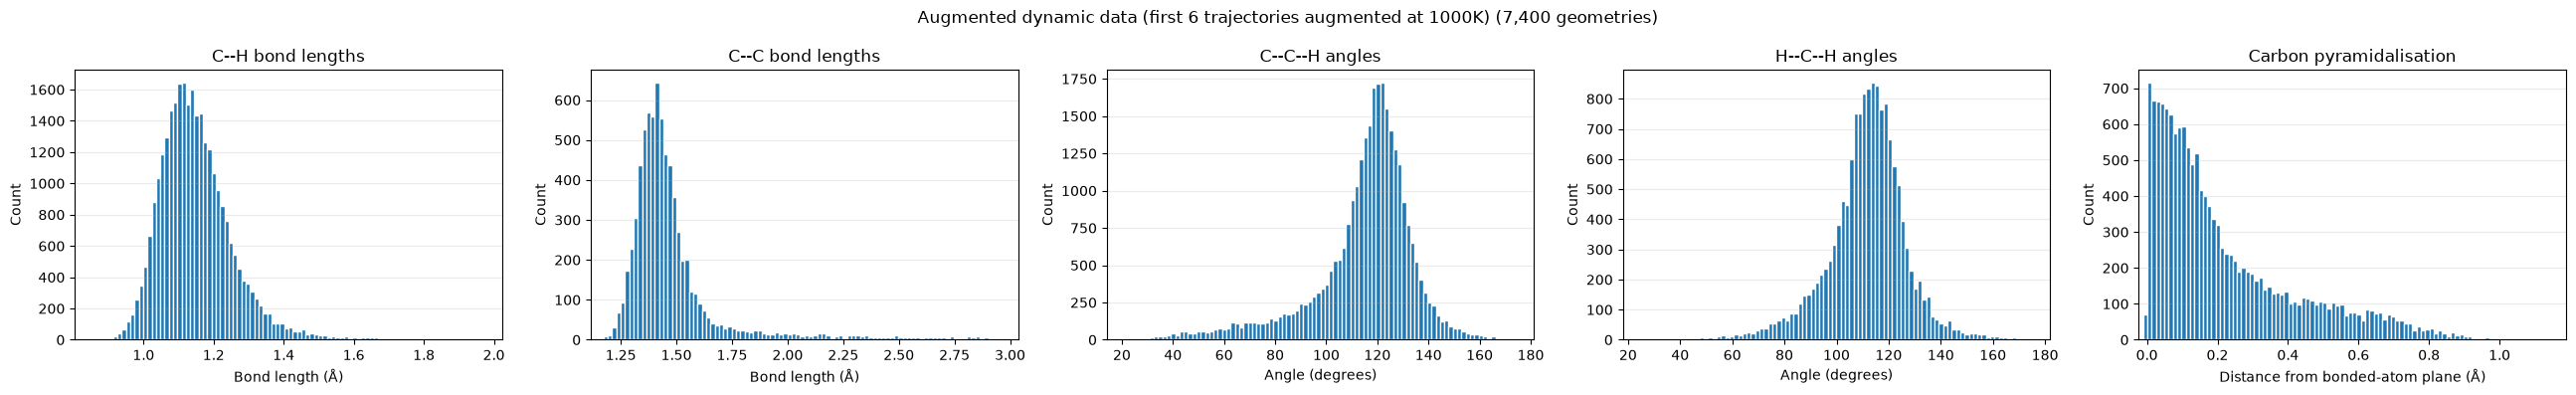

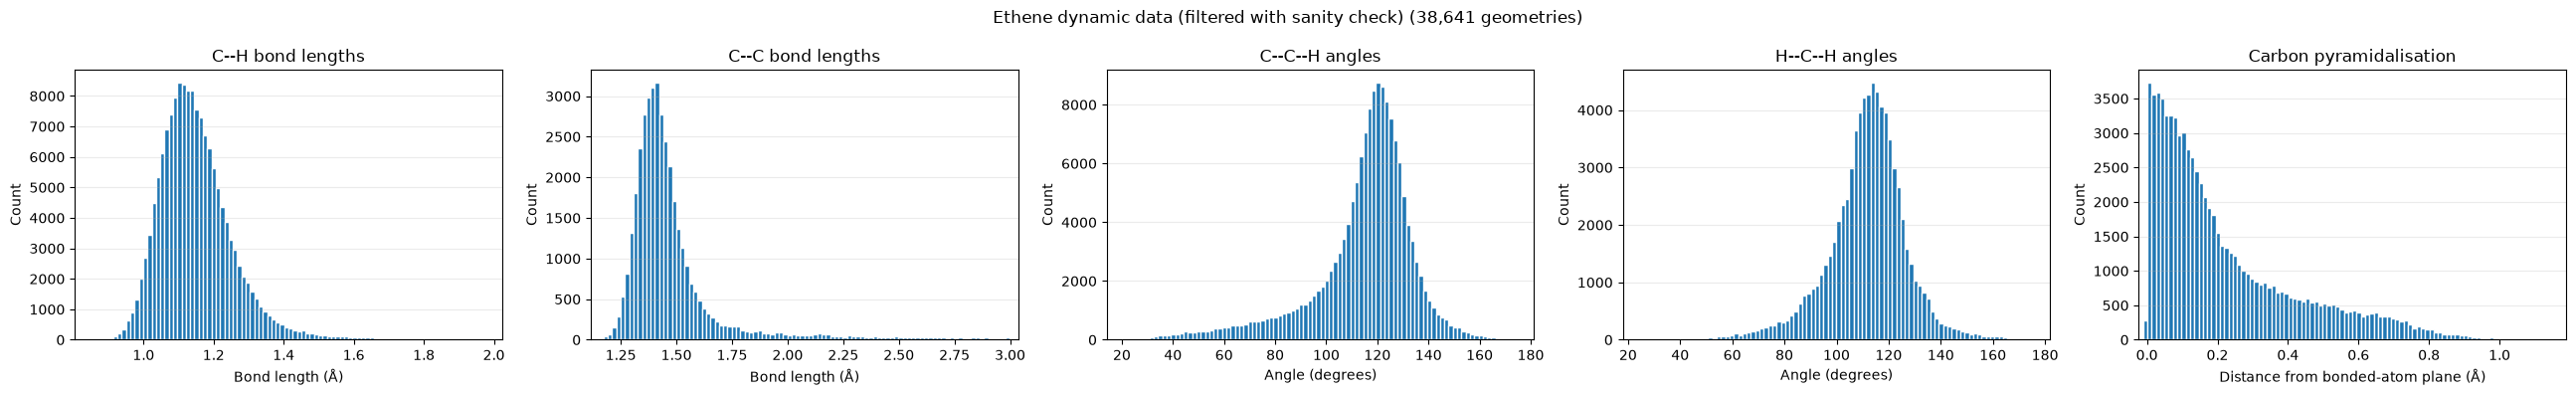

In [24]:
# Compare geometry distributions in an augmented XYZ file against its input XYZ file.
# This cell is standalone; set the two paths below for the files you want to compare.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ANALYSIS_XYZ = Path("../data/A01_ethene/dynamic/A01_ethene_dynamic_CASSCF_sanity_defaults_filtered_random_7400.xyz")
REFERENCE_XYZ = Path("../data/A01_ethene/dynamic_gitignore/A01_ethene_dynamic_CASSCF_sanity_defaults_filtered.xyz")

for label, xyz_path in (("ANALYSIS_XYZ", ANALYSIS_XYZ), ("REFERENCE_XYZ", REFERENCE_XYZ)):
    if not xyz_path.is_file():
        raise FileNotFoundError(f"{label} file not found: {xyz_path.resolve()}")

# Atom order is C, C, H, H, H, H in both extended-XYZ files.
CH_PAIRS = ((0, 2), (0, 5), (1, 3), (1, 4))
CCH_TRIPLES = ((1, 0, 2), (1, 0, 5), (0, 1, 3), (0, 1, 4))
HCH_TRIPLES = ((2, 0, 5), (3, 1, 4))
PYRAMIDALISATION_SITES = ((0, (1, 2, 5)), (1, (0, 3, 4)))


def angle_degrees(positions, atom_i, central_atom, atom_j):
    first = positions[atom_i] - positions[central_atom]
    second = positions[atom_j] - positions[central_atom]
    cosine = np.dot(first, second) / (np.linalg.norm(first) * np.linalg.norm(second))
    return float(np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0))))


def pyramidalisation(positions, carbon, plane_atoms):
    plane_origin, plane_atom1, plane_atom2 = positions[list(plane_atoms)]
    normal = np.cross(plane_atom1 - plane_origin, plane_atom2 - plane_origin)
    return float(abs(np.dot(positions[carbon] - plane_origin, normal)) / np.linalg.norm(normal))


def geometry_values(xyz_path):
    values = {
        "C--H": [], "C--C": [], "C--C--H": [], "H--C--H": [],
        "Pyramidalisation": [],
    }
    geometry_count = 0
    with xyz_path.open() as source:
        while atom_count_line := source.readline():
            atom_count = int(atom_count_line)
            source.readline()  # Extended-XYZ comment line.
            rows = [source.readline().split() for _ in range(atom_count)]
            if atom_count != 6 or [row[0] for row in rows] != ["C", "C", "H", "H", "H", "H"]:
                raise ValueError(f"Unexpected atom ordering in geometry {geometry_count} of {xyz_path}")
            positions = np.asarray([[float(value) for value in row[1:4]] for row in rows])
            values["C--C"].append(np.linalg.norm(positions[0] - positions[1]))
            values["C--H"].extend(np.linalg.norm(positions[i] - positions[j]) for i, j in CH_PAIRS)
            values["C--C--H"].extend(angle_degrees(positions, *atoms) for atoms in CCH_TRIPLES)
            values["H--C--H"].extend(angle_degrees(positions, *atoms) for atoms in HCH_TRIPLES)
            values["Pyramidalisation"].extend(
                pyramidalisation(positions, carbon, plane_atoms)
                for carbon, plane_atoms in PYRAMIDALISATION_SITES
            )
            geometry_count += 1
    if not geometry_count:
        raise ValueError(f"No geometries found in {xyz_path}")
    return geometry_count, values

PLOT_DEFINITIONS = (
    ("C--H", "C--H bond lengths", "Bond length (Å)"),
    ("C--C", "C--C bond lengths", "Bond length (Å)"),
    ("C--C--H", "C--C--H angles", "Angle (degrees)"),
    ("H--C--H", "H--C--H angles", "Angle (degrees)"),
    ("Pyramidalisation", "Carbon pyramidalisation", "Distance from bonded-atom plane (Å)"),
)


def shared_x_limits(*value_sets):
    limits = {}
    for key, _, _ in PLOT_DEFINITIONS:
        lower = min(np.min(values[key]) for values in value_sets)
        upper = max(np.max(values[key]) for values in value_sets)
        padding = 0.02 * (upper - lower) if upper > lower else max(0.01, 0.02 * abs(lower))
        limits[key] = (lower - padding, upper + padding)
    return limits


def plot_geometry_histograms(geometry_count, values, title, x_limits):
    fig, axes = plt.subplots(1, 5, figsize=(26, 4))
    for axis, (key, subplot_title, xlabel) in zip(axes, PLOT_DEFINITIONS):
        bins = np.linspace(*x_limits[key], num=101)
        axis.hist(values[key], bins=bins, color="tab:blue", edgecolor="white")
        axis.set(title=subplot_title, xlabel=xlabel, ylabel="Count", xlim=x_limits[key])
        axis.grid(axis="y", alpha=0.25)
    fig.suptitle(f"{title} ({geometry_count:,} geometries)")
    fig.tight_layout()
    plt.show()


analysis_count, analysis_values = geometry_values(ANALYSIS_XYZ)
reference_count, reference_values = geometry_values(REFERENCE_XYZ)
# Use the reference distribution alone to define the plotted x-axis ranges.
shared_limits = shared_x_limits(reference_values)

plot_geometry_histograms(
    analysis_count, analysis_values, "Augmented dynamic data (first 6 trajectories augmented at 1000K)", shared_limits
)
plot_geometry_histograms(
    reference_count, reference_values, "Ethene dynamic data (filtered with sanity check)", shared_limits
)


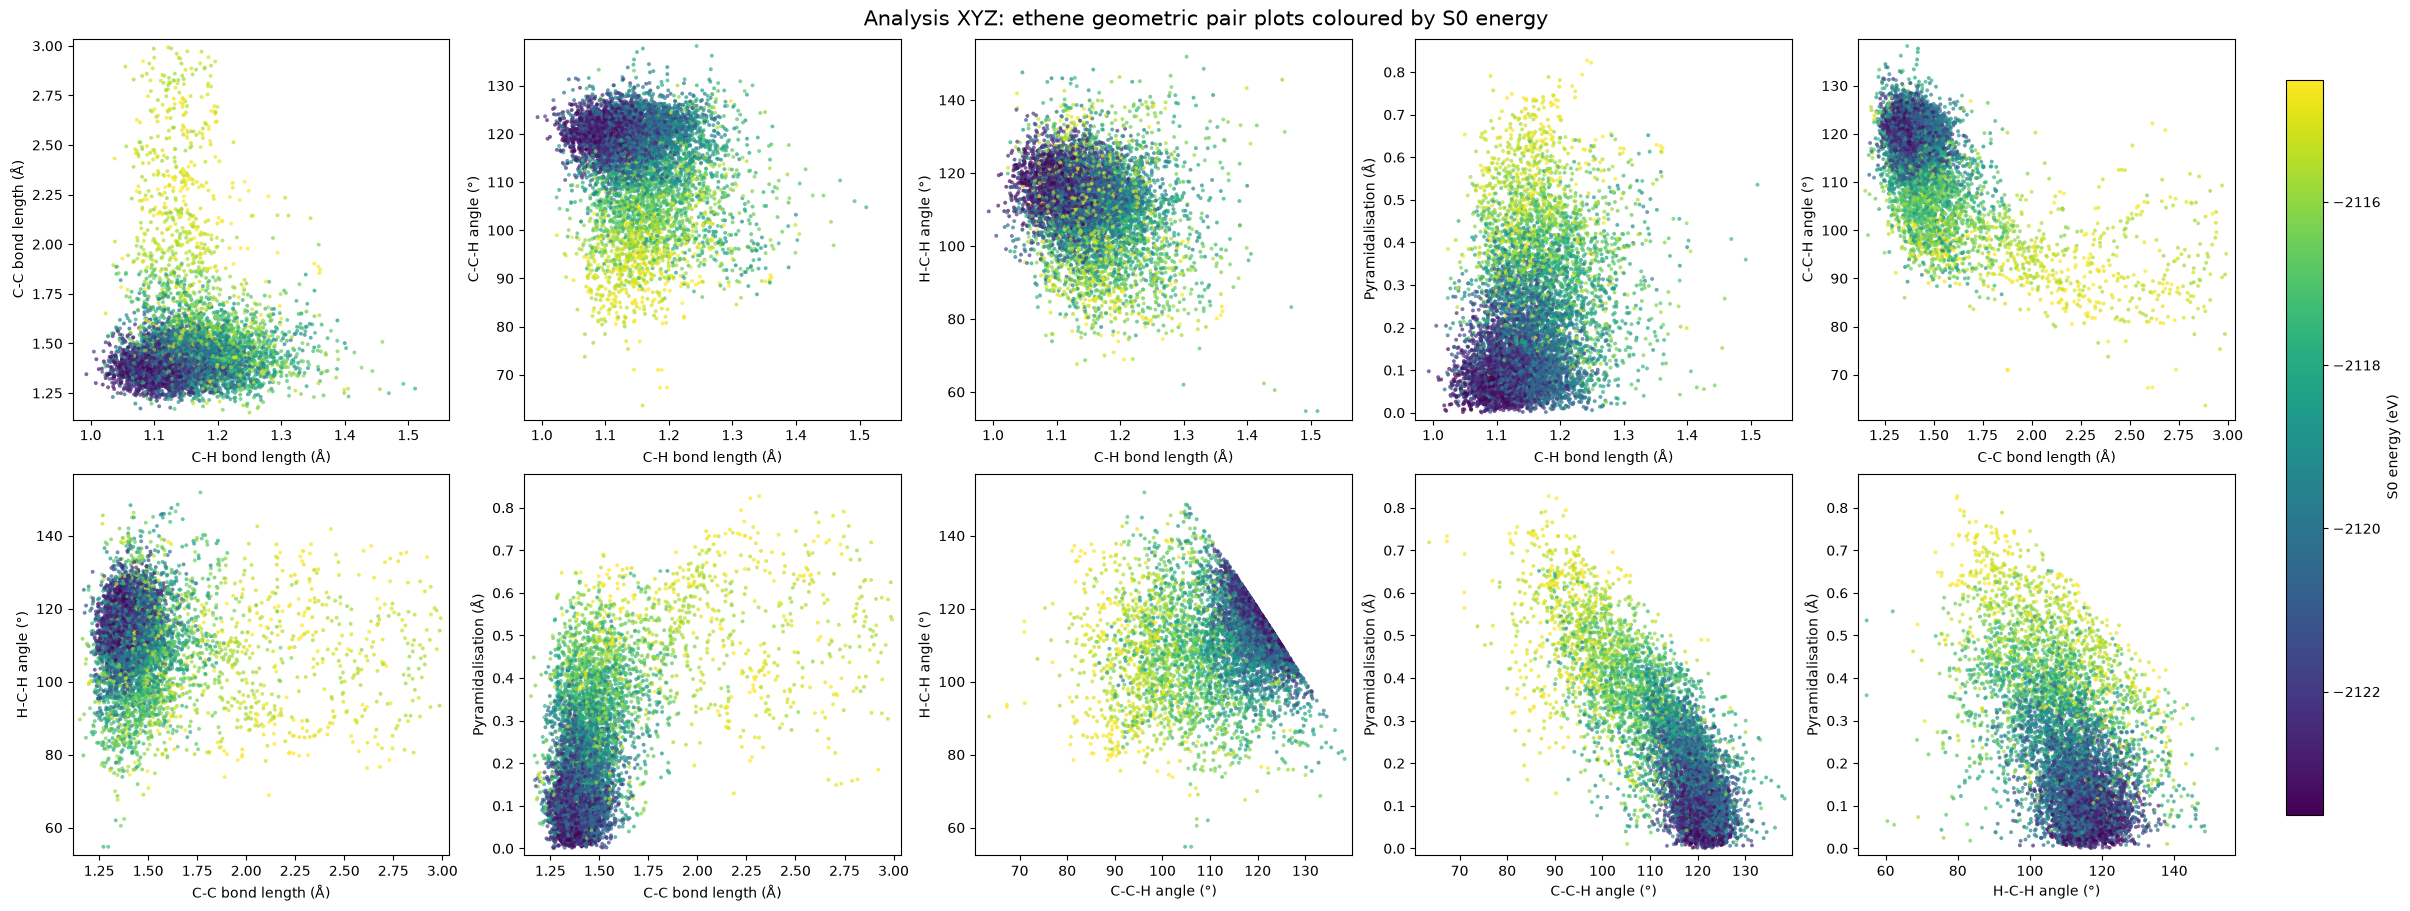

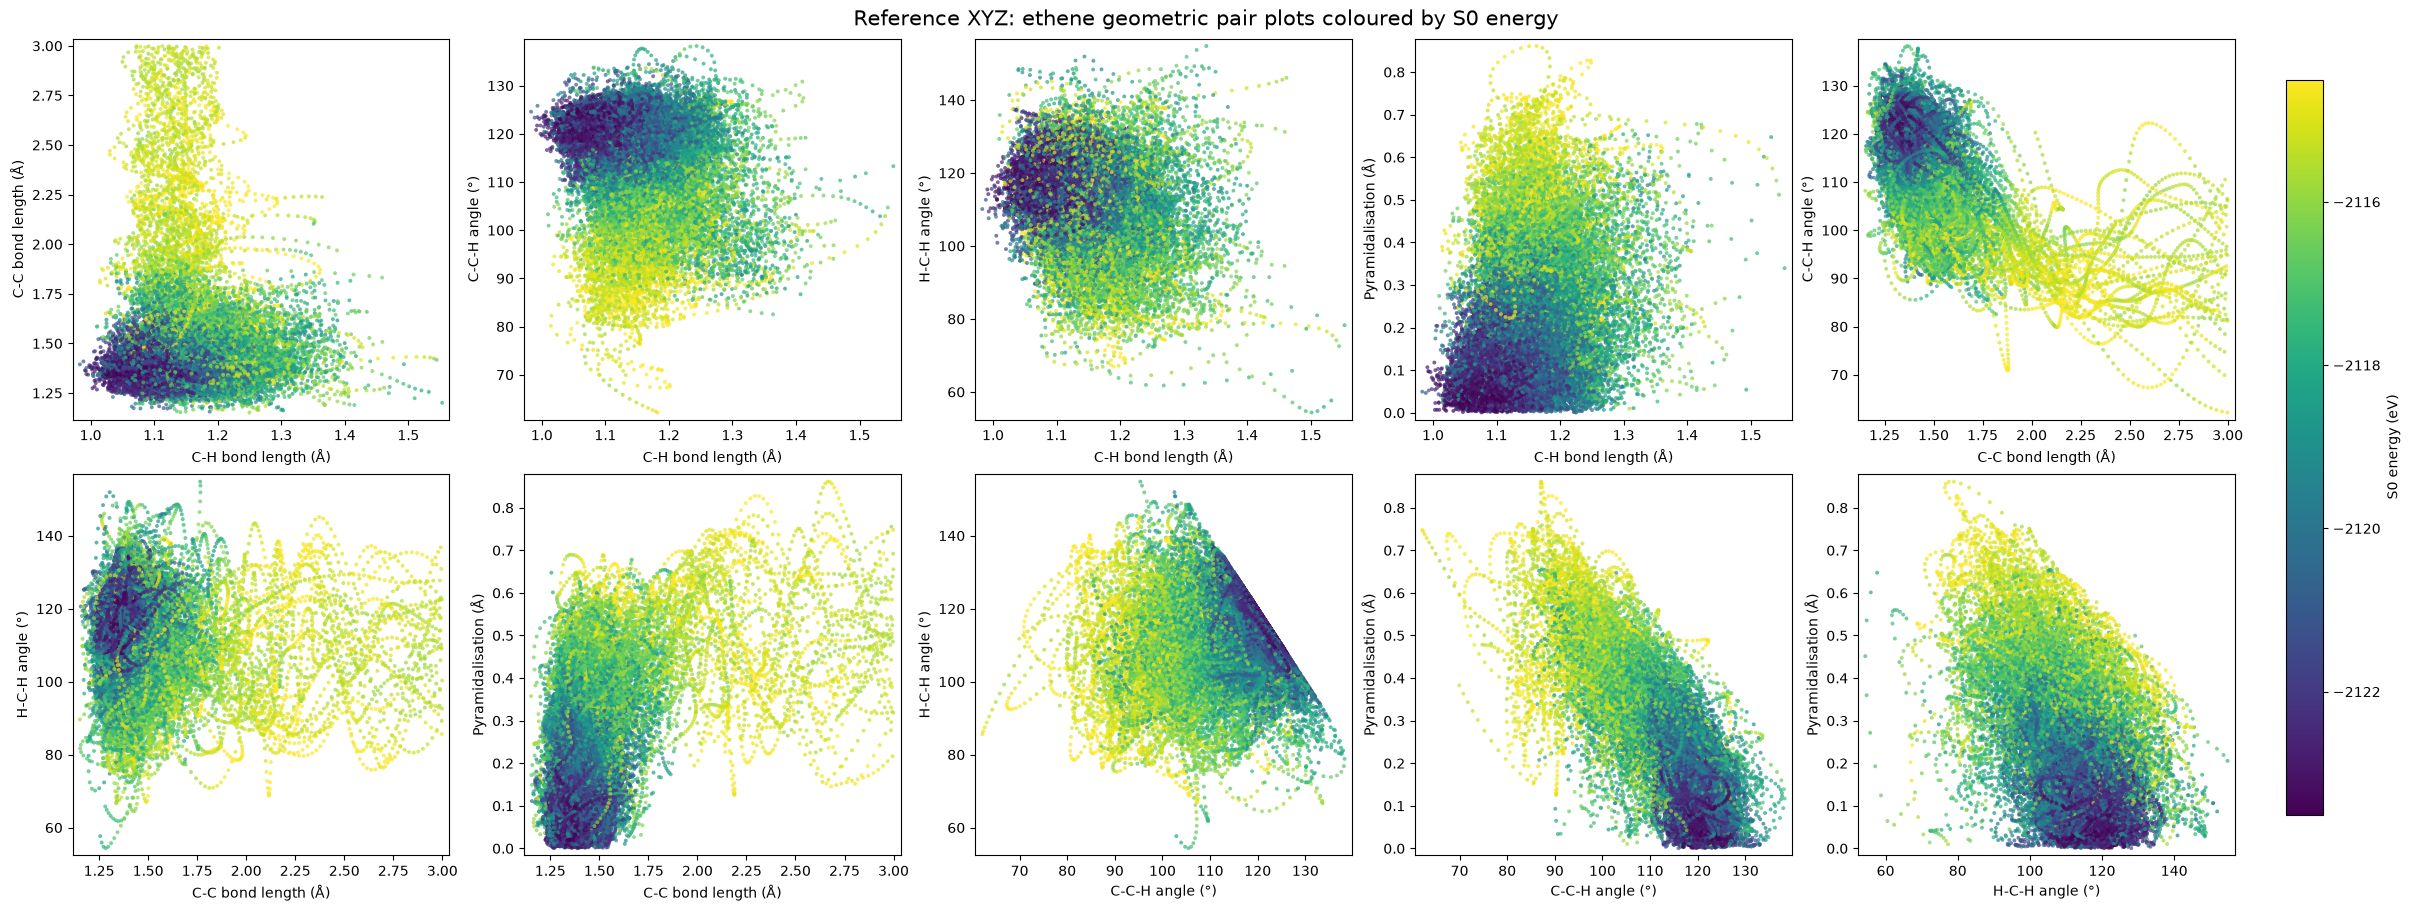

In [25]:
# Pairwise ethene geometry relationships, coloured by one selected electronic-state energy.
from itertools import combinations

from ase.io import iread

SELECTED_STATE = 0  # S0; set to 1 or 2 for the other available electronic states.

def mean_geometry_coordinates(frame):
    positions = frame.get_positions()
    return {
        "C-H bond length (Å)": np.mean([np.linalg.norm(positions[i] - positions[j]) for i, j in CH_PAIRS]),
        "C-C bond length (Å)": np.linalg.norm(positions[0] - positions[1]),
        "C-C-H angle (°)": np.mean([angle_degrees(positions, *atoms) for atoms in CCH_TRIPLES]),
        "H-C-H angle (°)": np.mean([angle_degrees(positions, *atoms) for atoms in HCH_TRIPLES]),
        "Pyramidalisation (Å)": np.mean([
            pyramidalisation(positions, carbon, plane_atoms)
            for carbon, plane_atoms in PYRAMIDALISATION_SITES
        ]),
    }

def load_ethene_pairwise_data(xyz_path):
    geometry_data = None
    state_energies = []
    for geometry_index, frame in enumerate(iread(xyz_path, index=":")):
        if frame.get_chemical_symbols() != ["C", "C", "H", "H", "H", "H"]:
            raise ValueError(f"Unexpected ethene atom ordering in geometry {geometry_index} of {xyz_path}.")
        if "REF_energy" not in frame.info:
            raise KeyError(f"REF_energy is missing from geometry {geometry_index} of {xyz_path}.")
        energies = np.asarray(frame.info["REF_energy"], dtype=float).reshape(-1)
        if not np.isfinite(energies).all():
            raise ValueError(f"REF_energy contains non-finite values in geometry {geometry_index} of {xyz_path}.")
        coordinates = mean_geometry_coordinates(frame)
        if geometry_data is None:
            geometry_data = {key: [] for key in coordinates}
        for key, value in coordinates.items():
            geometry_data[key].append(value)
        state_energies.append(energies)
    if geometry_data is None:
        raise ValueError(f"No geometries found in {xyz_path}.")
    geometry_data = {key: np.asarray(values) for key, values in geometry_data.items()}
    state_energies = np.vstack(state_energies)
    if not all(np.isfinite(values).all() for values in geometry_data.values()):
        raise ValueError(f"Derived geometry coordinates contain non-finite values in {xyz_path}.")
    return geometry_data, state_energies

analysis_geometry_data, analysis_state_energies_ev = load_ethene_pairwise_data(ANALYSIS_XYZ)
reference_geometry_data, reference_state_energies_ev = load_ethene_pairwise_data(REFERENCE_XYZ)
if analysis_state_energies_ev.shape[1] != reference_state_energies_ev.shape[1]:
    raise ValueError("ANALYSIS_XYZ and REFERENCE_XYZ have different numbers of electronic states.")
if not 0 <= SELECTED_STATE < analysis_state_energies_ev.shape[1]:
    raise ValueError(f"SELECTED_STATE must be between 0 and {analysis_state_energies_ev.shape[1] - 1}.")

GEOMETRY_COORDINATES = list(reference_geometry_data)
def padded_limits(values):
    lower, upper = float(np.min(values)), float(np.max(values))
    padding = 0.02 * (upper - lower) if upper > lower else max(0.01, 0.02 * abs(lower))
    return lower - padding, upper + padding

# Geometry limits are deliberately fixed from REFERENCE_XYZ for direct comparison.
coordinate_limits = {key: padded_limits(values) for key, values in reference_geometry_data.items()}
reference_selected_energies_ev = reference_state_energies_ev[:, SELECTED_STATE]
analysis_selected_energies_ev = analysis_state_energies_ev[:, SELECTED_STATE]
energy_norm = plt.Normalize(*np.percentile(reference_selected_energies_ev, (1.0, 99.0)))

def plot_energy_coloured_pairs(dataset_name, geometry_data, selected_energies_ev):
    figure, axes = plt.subplots(2, 5, figsize=(24, 9), constrained_layout=True)
    for axis, (x_coordinate, y_coordinate) in zip(axes.flat, combinations(GEOMETRY_COORDINATES, 2)):
        axis.scatter(
            geometry_data[x_coordinate], geometry_data[y_coordinate],
            c=selected_energies_ev, cmap="viridis", norm=energy_norm, s=8, alpha=0.7, linewidths=0, rasterized=True,
        )
        axis.set(xlim=coordinate_limits[x_coordinate], ylim=coordinate_limits[y_coordinate], xlabel=x_coordinate, ylabel=y_coordinate)
    colorbar = figure.colorbar(
        plt.cm.ScalarMappable(norm=energy_norm, cmap="viridis"), ax=axes.ravel().tolist(), shrink=0.9, pad=0.02
    )
    colorbar.set_label(f"S{SELECTED_STATE} energy (eV)")
    figure.suptitle(f"{dataset_name}: ethene geometric pair plots coloured by S{SELECTED_STATE} energy", fontsize=15)
    plt.show()

plot_energy_coloured_pairs("Analysis XYZ", analysis_geometry_data, analysis_selected_energies_ev)
plot_energy_coloured_pairs("Reference XYZ", reference_geometry_data, reference_selected_energies_ev)
